# TODO:

1. deal with duplicate genes --> remove for now (eventually calculate correlation matrix of duplicate genes)
2. new normalization (quantile binning?)
3. Test many architectures
4. Maybe train on latent embedding representation of other models? SCVI? --> yes it can be done 

* .

5. Complete EDA with PCA, T-SNE, UMAP plots also for preprocessing techniques. 
6. Add correlation study, matrix gene by gene, gene by alteration. 
7. (Optional) Check for non-coding genes and remove them 

* .

8. Discuss and analyze which are the better normalization technique to use 

9. Models 

10. Find dataset for second task: multi-class classification



In [4]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

## Import data

In [5]:
mutation = pd.read_csv("data/sample_matrix.txt", sep="\t")
mutation[['gene_symbol', 'Hugo_Symbol']] = mutation['studyID:sampleId'].str.split(':', expand=True)
mutation = mutation[['Hugo_Symbol', 'Altered', 'TP53']]
mutation

,Hugo_Symbol,Altered,TP53
0,SJRH30_SOFT_TISSUE,1,1
1,FADU_UPPER_AERODIGESTIVE_TRACT,1,1
2,HH_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,1,1
3,SKNMC_BONE,0,0
4,SNU182_LIVER,1,1
...,...,...,...
1565,HUH6CLONE5_LIVER,1,1
1566,CROAP3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0,0
1567,ACN_AUTONOMIC_GANGLIA,1,1
1568,YAMATO_SOFT_TISSUE,1,1


In [6]:
rna = pd.read_csv("data/ccle_broad_2019/data_mrna_seq_rpkm.txt", sep="\t").T.reset_index()
rna.columns = rna.iloc[0]
rna = rna[1:] 
rna

,Hugo_Symbol,DDX11L1,WASH7P,MIR1302-11,FAM138A,OR4G4P,OR4G11P,OR4F5,RP11-34P13.7,CICP27,...,MT-ND3,MT-TR,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT
1,22RV1_PROSTATE,0.0,12.63011,0.04289,0.0,0.0,0.0,0.0,0.44714,0.37909,...,1176.81189,0.0,0.0,0.0,0.12335,2393.80298,1825.52332,0.25386,4923.78223,0.0
2,2313287_STOMACH,0.03755,10.14155,0.01037,0.00869,0.0,0.0,0.0,0.34327,0.09168,...,1009.34979,0.0,0.0,0.0,0.0,1960.96802,2056.64697,0.0,3827.00537,0.0
3,253JBV_URINARY_TRACT,0.0,6.20657,0.16955,0.22423,0.02886,0.01939,0.0,0.16982,0.10995,...,2816.78296,0.0,0.39614,0.0,0.51331,1896.2887,2184.88647,0.2641,1905.18481,0.0
4,253J_URINARY_TRACT,0.06507,6.55835,0.23364,0.16558,0.03875,0.03904,0.0,0.08922,0.09146,...,7116.30469,0.14115,0.26594,0.0,1.03378,3522.37695,4568.00195,0.0,4590.01416,0.0
5,42MGBA_CENTRAL_NERVOUS_SYSTEM,0.0,7.61752,0.08765,0.0,0.0,0.0,0.0,0.09428,0.07513,...,1049.68384,0.13768,0.0,0.0,0.25209,1178.93579,1616.96484,0.1297,2343.92407,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1152,UMUC9_URINARY_TRACT,0.03236,8.70551,0.07747,0.0,0.00642,0.0,0.01325,0.02958,0.10214,...,2820.28882,0.0936,0.0,0.0,0.0,1452.41895,996.53717,0.08817,3437.12769,0.0
1153,UPCISCC152_UPPER_AERODIGESTIVE_TRACT,0.0,15.23348,0.07448,0.02674,0.0,0.0,0.0,0.04402,0.08265,...,995.5639,0.16713,0.0,0.0,0.30602,793.5871,593.61139,0.31489,1645.22168,0.0
1154,UW228_CENTRAL_NERVOUS_SYSTEM,0.03799,6.47732,0.01049,0.00879,0.0,0.02279,0.0,0.06945,0.01686,...,441.25647,0.16482,0.0,0.0,0.0,757.41357,472.01627,0.15526,973.56439,0.16232
1155,Y79_AUTONOMIC_GANGLIA,0.02907,8.45568,0.39607,0.26449,0.0,0.01163,0.01191,0.07971,0.09748,...,2341.42505,0.50444,0.2376,0.27787,0.92361,1218.16992,729.65912,0.55439,1221.39954,0.0828


In [32]:
data = pd.merge(mutation, rna, on='Hugo_Symbol', how='inner')
data[['prefix', 'tissue']] = data['Hugo_Symbol'].str.split('_', n=1, expand=True)
data

,Hugo_Symbol,Altered,TP53_x,DDX11L1,WASH7P,MIR1302-11,FAM138A,OR4G4P,OR4G11P,OR4F5,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,prefix,tissue
0,FADU_UPPER_AERODIGESTIVE_TRACT,1,1,0.0,5.1835,0.01052,0.0,0.0,0.0,0.0234,...,0.0,0.0,0.0,1317.52258,1196.75122,0.31135,1787.94458,0.0,FADU,UPPER_AERODIGESTIVE_TRACT
1,HH_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,1,1,0.05643,5.72749,0.25718,0.34596,0.16805,0.13544,0.13002,...,0.11532,0.13487,0.22414,1635.74133,1838.11011,0.23064,2874.67969,0.0,HH,HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,SKNMC_BONE,0,0,0.08199,11.74241,0.06793,0.01264,0.0,0.0,0.0,...,0.11169,0.13062,0.32564,1303.24939,1671.89966,0.22338,2865.82617,0.11677,SKNMC,BONE
3,SNU182_LIVER,1,1,0.14469,4.22183,0.11323,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1084.13037,1245.69885,0.0,1161.77368,0.0,SNU182,LIVER
4,BT20_BREAST,1,1,0.36092,7.45707,0.13291,0.0,0.0,0.0,0.0,...,0.09834,0.0,0.09557,1906.21631,2321.45166,0.29501,4161.57129,0.0,BT20,BREAST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,C33A_CERVIX,1,1,0.07761,7.21211,0.25186,0.01346,0.00578,0.02328,0.0,...,0.23788,0.37093,0.84766,2129.98291,1399.54785,0.63435,2283.80151,0.0,C33A,CERVIX
1122,SW982_SOFT_TISSUE,0,0,0.0,5.06211,0.14717,0.01298,0.0,0.0,0.0,...,0.0,0.0,0.11138,512.84479,310.11151,0.22923,668.37408,0.0,SW982,SOFT_TISSUE
1123,GIMEN_AUTONOMIC_GANGLIA,0,0,0.00963,5.40782,0.13299,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0765,663.47522,351.89856,0.23615,1586.69495,0.0823,GIMEN,AUTONOMIC_GANGLIA
1124,YAMATO_SOFT_TISSUE,1,1,0.0,11.81688,0.17586,0.02266,0.01459,0.01469,0.0,...,0.20018,0.0,0.0,1320.84558,564.16779,0.0,1755.82764,0.20928,YAMATO,SOFT_TISSUE


## Pre-processing

### Duplicates (initially remove all duplicates: 1956 columns, 216 gene repeated) 

In [36]:
# check for duplicated columns
duplicated_columns = data.columns[data.columns.duplicated()].unique()
if len(duplicated_columns) > 0:
    print(f"Duplicated columns: {duplicated_columns}")
else:
    print("No duplicated columns found.")

Duplicated columns: Index(['Y_RNA', 'ENO1', 'snoU13', 'U1', 'SNORA63', 'SNORD112', 'BTBD8',
       'SNORA66', 'SCARNA16', 'U3',
       ...
       'SPRY3', 'AMDP1', 'DPH3P2', 'VAMP7', 'TCEB1P24', 'TRPC6P1', 'IL9R',
       'AJ271736.10', 'WASIR1', 'DDX11L16'],
      dtype='object', length=216)


In [33]:
# count how many diplicates in total 
duplicated_count = data.columns.duplicated().sum()
print(f"Total duplicated columns: {duplicated_count}")

Total duplicated columns: 1965


In [27]:
# check for duplicated rows
duplicated_rows = data[data.duplicated()]
if len(duplicated_rows) > 0:
    print(f"Duplicated rows: {len(duplicated_rows)}")
else:
    print("No duplicated rows found.")

No duplicated rows found.


In [29]:
# remove duplicates 
data = data.loc[:, ~data.columns.duplicated()]
data


,Hugo_Symbol,Altered,TP53_x,DDX11L1,WASH7P,MIR1302-11,FAM138A,OR4G4P,OR4G11P,OR4F5,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,prefix,tissue
0,FADU_UPPER_AERODIGESTIVE_TRACT,1,1,0.0,5.1835,0.01052,0.0,0.0,0.0,0.0234,...,0.0,0.0,0.0,1317.52258,1196.75122,0.31135,1787.94458,0.0,FADU,UPPER_AERODIGESTIVE_TRACT
1,HH_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,1,1,0.05643,5.72749,0.25718,0.34596,0.16805,0.13544,0.13002,...,0.11532,0.13487,0.22414,1635.74133,1838.11011,0.23064,2874.67969,0.0,HH,HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,SKNMC_BONE,0,0,0.08199,11.74241,0.06793,0.01264,0.0,0.0,0.0,...,0.11169,0.13062,0.32564,1303.24939,1671.89966,0.22338,2865.82617,0.11677,SKNMC,BONE
3,SNU182_LIVER,1,1,0.14469,4.22183,0.11323,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1084.13037,1245.69885,0.0,1161.77368,0.0,SNU182,LIVER
4,BT20_BREAST,1,1,0.36092,7.45707,0.13291,0.0,0.0,0.0,0.0,...,0.09834,0.0,0.09557,1906.21631,2321.45166,0.29501,4161.57129,0.0,BT20,BREAST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,C33A_CERVIX,1,1,0.07761,7.21211,0.25186,0.01346,0.00578,0.02328,0.0,...,0.23788,0.37093,0.84766,2129.98291,1399.54785,0.63435,2283.80151,0.0,C33A,CERVIX
1122,SW982_SOFT_TISSUE,0,0,0.0,5.06211,0.14717,0.01298,0.0,0.0,0.0,...,0.0,0.0,0.11138,512.84479,310.11151,0.22923,668.37408,0.0,SW982,SOFT_TISSUE
1123,GIMEN_AUTONOMIC_GANGLIA,0,0,0.00963,5.40782,0.13299,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0765,663.47522,351.89856,0.23615,1586.69495,0.0823,GIMEN,AUTONOMIC_GANGLIA
1124,YAMATO_SOFT_TISSUE,1,1,0.0,11.81688,0.17586,0.02266,0.01459,0.01469,0.0,...,0.20018,0.0,0.0,1320.84558,564.16779,0.0,1755.82764,0.20928,YAMATO,SOFT_TISSUE


### Standardization

In [8]:
X = data.drop(columns=['Hugo_Symbol', 'Altered','TP53_x', 'prefix', 'tissue']) 
y = list(data['tissue'])

X_num = X.apply(pd.to_numeric, errors='coerce')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Log normalization

In [9]:
# Log transform the RPKM values
X_log = np.log2(X_num + 1)

# Standardize the data (z-score normalization)
X_log = scaler.fit_transform(X_log)

# Verify the standardization
print("Mean of each feature after standardization:", np.mean(X_log, axis=0))
print("Standard deviation of each feature after standardization:", np.std(X_log, axis=0))

Mean of each feature after standardization: [-9.14997306e-17 -3.72309249e-16 -7.09911703e-17 ...  6.31032625e-17
 -1.32516851e-16 -2.20861419e-17]
Standard deviation of each feature after standardization: [1. 1. 1. ... 1. 1. 1.]


### CPM normalization

In [10]:
# Calculate total counts per cell
total_counts = X.sum(axis=1)

# Perform CPM normalization
# Convert to float to avoid integer division
counts_arr = total_counts.to_numpy()[:, np.newaxis]
X_cpm = (X.astype(float) / counts_arr) * 1e6

# Verify the normalization
print("Total counts per cell after CPM normalization:", X_cpm.sum(axis=1))
print("\nSummary statistics of CPM normalized data:")
print(pd.DataFrame(X_cpm).describe())

# Log transform the CPM values (not RPKM as previously stated)
X_cpm_log = np.log2(X_cpm.apply(pd.to_numeric, errors='coerce') + 1)

# Standardize the data (z-score normalization)
X_cpm_log = scaler.fit_transform(X_cpm_log)

# Verify the standardization
print("\nMean of each feature after standardization:", np.mean(X_cpm_log, axis=0))
print("Standard deviation of each feature after standardization:", np.std(X_cpm_log, axis=0))

Total counts per cell after CPM normalization: 0       1000000.0
1       1000000.0
2       1000000.0
3       1000000.0
4       1000000.0
          ...    
1121    1000000.0
1122    1000000.0
1123    1000000.0
1124    1000000.0
1125    1000000.0
Length: 1126, dtype: object

Summary statistics of CPM normalized data:
        DDX11L1       WASH7P  MIR1302-11  FAM138A  OR4G4P  OR4G11P   OR4F5  \
count    1126.0  1126.000000      1126.0   1126.0  1126.0   1126.0  1126.0   
unique    819.0  1126.000000      1068.0    474.0   151.0    147.0   131.0   
top         0.0    13.822557         0.0      0.0     0.0      0.0     0.0   
freq      308.0     1.000000        59.0    653.0   976.0    980.0   996.0   

        RP11-34P13.7       CICP27   AL627309.1  ...       MT-ND3   MT-TR  \
count         1126.0  1126.000000  1126.000000  ...  1126.000000  1126.0   
unique        1118.0  1126.000000  1126.000000  ...  1126.000000   402.0   
top              0.0     1.097058    21.926947  ...  5202.260319

## EDA

### T-SNE

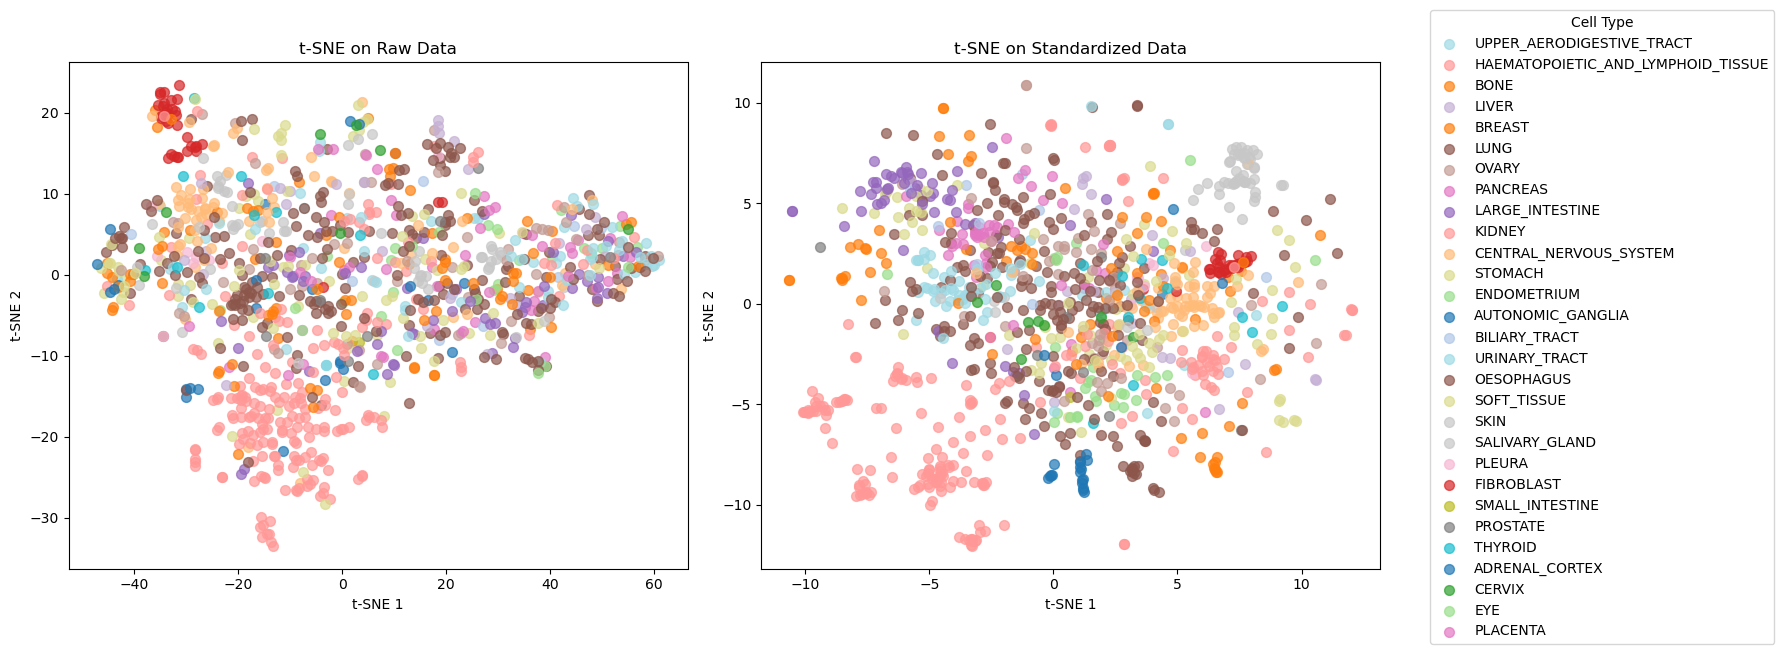

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(X_scaled)

# Create a color map for different cell types
unique_cells = list(set(y))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5']
cell_to_color = {cell: colors[i % len(colors)] for i, cell in enumerate(unique_cells)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: t-SNE on raw data ---
tsne_raw = TSNE(n_components=2, random_state=42)
emb_raw = tsne_raw.fit_transform(X)

plotted = set()
for i, label in enumerate(y):
    if label not in plotted:
        ax1.scatter(emb_raw[i, 0], emb_raw[i, 1],
                    color=cell_to_color[label],
                    label=label,
                    alpha=0.7, s=50)
        plotted.add(label)
    else:
        ax1.scatter(emb_raw[i, 0], emb_raw[i, 1],
                    color=cell_to_color[label],
                    alpha=0.7, s=50)

ax1.set_title("t-SNE on Raw Data")
ax1.set_xlabel("t-SNE 1")
ax1.set_ylabel("t-SNE 2")

# --- Right panel: t-SNE on standardized data ---
tsne_scaled = TSNE(n_components=2, random_state=42)
emb_scaled = tsne_scaled.fit_transform(X_scaled)

plotted = set()
for i, label in enumerate(y):
    if label not in plotted:
        ax2.scatter(emb_scaled[i, 0], emb_scaled[i, 1],
                    color=cell_to_color[label],
                    label=label,
                    alpha=0.7, s=50)
        plotted.add(label)
    else:
        ax2.scatter(emb_scaled[i, 0], emb_scaled[i, 1],
                    color=cell_to_color[label],
                    alpha=0.7, s=50)

ax2.set_title("t-SNE on Standardized Data")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")

# Single legend for both subplots
handles, labels_ = ax2.get_legend_handles_labels()
fig.legend(handles, labels_, title="Cell Type",
           bbox_to_anchor=(1.02, 0.5), loc='center left')

plt.tight_layout()
plt.show()

### PCA

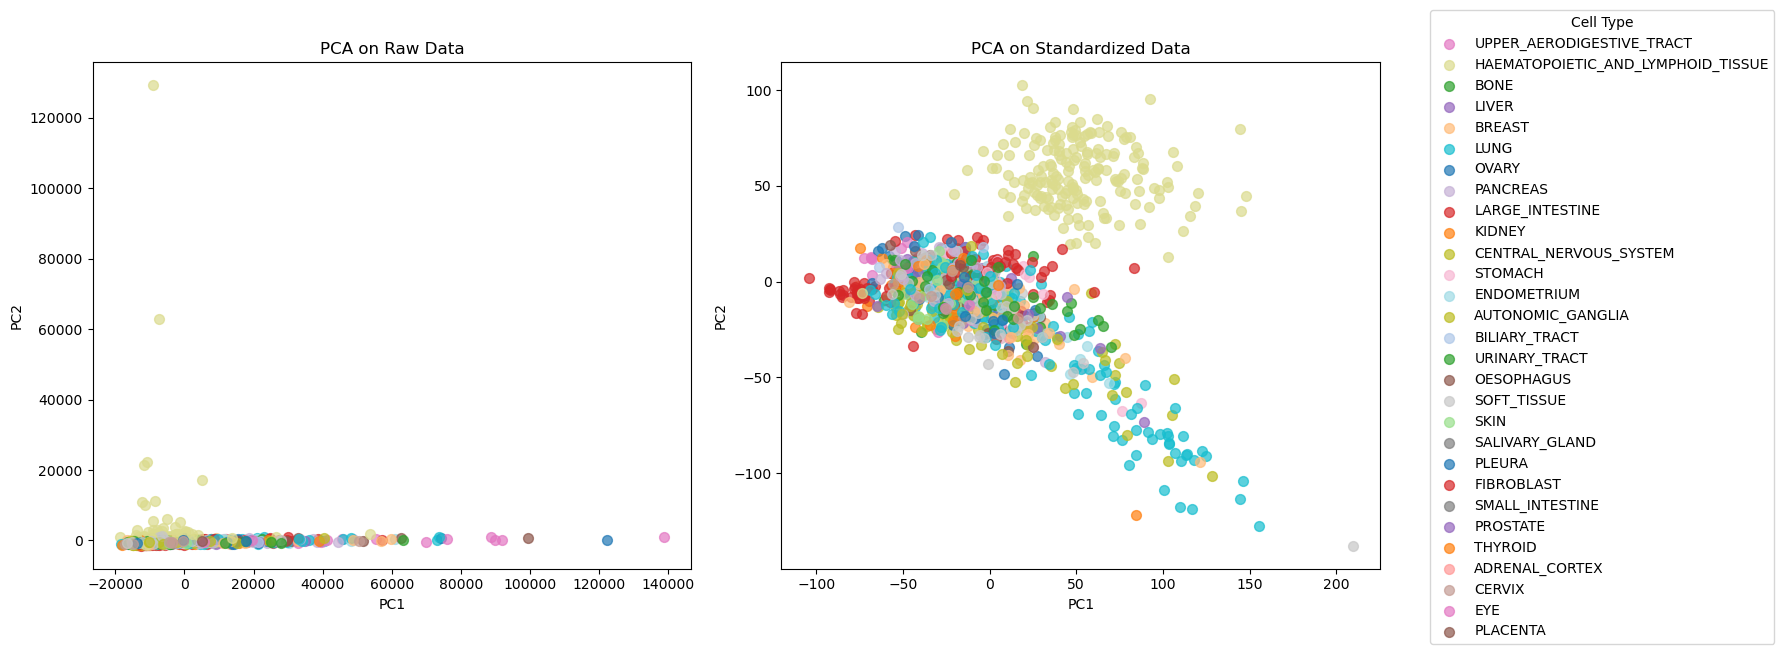

In [ ]:
# Create a 1×2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Common PCA object (or separate, but same params)
pca = PCA(n_components=2, random_state=42)

# --- Left plot: PCA on raw data X ---
pca_raw = pca.fit_transform(X)
for i, label in enumerate(y):
    ax1.scatter(pca_raw[i, 0], pca_raw[i, 1],
                color=cell_to_color[label],
                label=label if i == list(y).index(label) else "",
                alpha=0.7, s=50)
ax1.set_title("PCA on Raw Data")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# --- Right plot: PCA on standardized data X_scaled ---
pca_scaled = pca.fit_transform(X_scaled)
for i, label in enumerate(y):
    ax2.scatter(pca_scaled[i, 0], pca_scaled[i, 1],
                color=cell_to_color[label],
                label=label if i == list(y).index(label) else "",
                alpha=0.7, s=50)
ax2.set_title("PCA on Standardized Data")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

# Create a single legend for both axes
handles, labels_ = ax2.get_legend_handles_labels()
fig.legend(handles, labels_, title="Cell Type",
           bbox_to_anchor=(1.02, 0.5), loc='center left')

plt.tight_layout()
plt.show()

### Main genes

### TP53 analysis

In [45]:
sum(data["Altered"] == data["TP53_x"])

1126

## Models

In [ ]:
y = data["TP53_x"]
X_scaled

,DDX11L1,WASH7P,MIR1302-11,FAM138A,OR4G4P,OR4G11P,OR4F5,RP11-34P13.7,CICP27,AL627309.1,...,MT-ND3,MT-TR,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT
0,0.0,5.1835,0.01052,0.0,0.0,0.0,0.0234,0.27855,0.4114,8.22267,...,1950.86304,0.0,0.0,0.0,0.0,1317.52258,1196.75122,0.31135,1787.94458,0.0
1,0.05643,5.72749,0.25718,0.34596,0.16805,0.13544,0.13002,2.07631,0.21917,1.97955,...,3044.01099,0.0,0.11532,0.13487,0.22414,1635.74133,1838.11011,0.23064,2874.67969,0.0
2,0.08199,11.74241,0.06793,0.01264,0.0,0.0,0.0,0.06245,0.093,3.45513,...,2070.45264,0.11856,0.11169,0.13062,0.32564,1303.24939,1671.89966,0.22338,2865.82617,0.11677
3,0.14469,4.22183,0.11323,0.0,0.0,0.0,0.0,0.15431,0.13023,2.46623,...,1123.89685,0.0,0.0,0.0,0.0,1084.13037,1245.69885,0.0,1161.77368,0.0
4,0.36092,7.45707,0.13291,0.0,0.0,0.0,0.0,0.26393,0.4183,18.10178,...,1813.02844,0.0,0.09834,0.0,0.09557,1906.21631,2321.45166,0.29501,4161.57129,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,0.07761,7.21211,0.25186,0.01346,0.00578,0.02328,0.0,0.17292,0.12487,0.92113,...,3846.5,0.25252,0.23788,0.37093,0.84766,2129.98291,1399.54785,0.63435,2283.80151,0.0
1122,0.0,5.06211,0.14717,0.01298,0.0,0.0,0.0,0.04486,0.03734,0.47254,...,730.42224,0.0,0.0,0.0,0.11138,512.84479,310.11151,0.22923,668.37408,0.0
1123,0.00963,5.40782,0.13299,0.0,0.0,0.0,0.0,0.16286,0.04987,0.24902,...,3397.99438,0.0,0.0,0.0,0.0765,663.47522,351.89856,0.23615,1586.69495,0.0823
1124,0.0,11.81688,0.17586,0.02266,0.01459,0.01469,0.0,0.05597,0.36233,1.28208,...,904.73688,0.21249,0.20018,0.0,0.0,1320.84558,564.16779,0.0,1755.82764,0.20928


In [38]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Baseline

In [39]:
# Initialize and train XGBoost classifier
xgb_clf = xgb.XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [40]:
# Make predictions and calculate accuracy
y_pred = xgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8761
